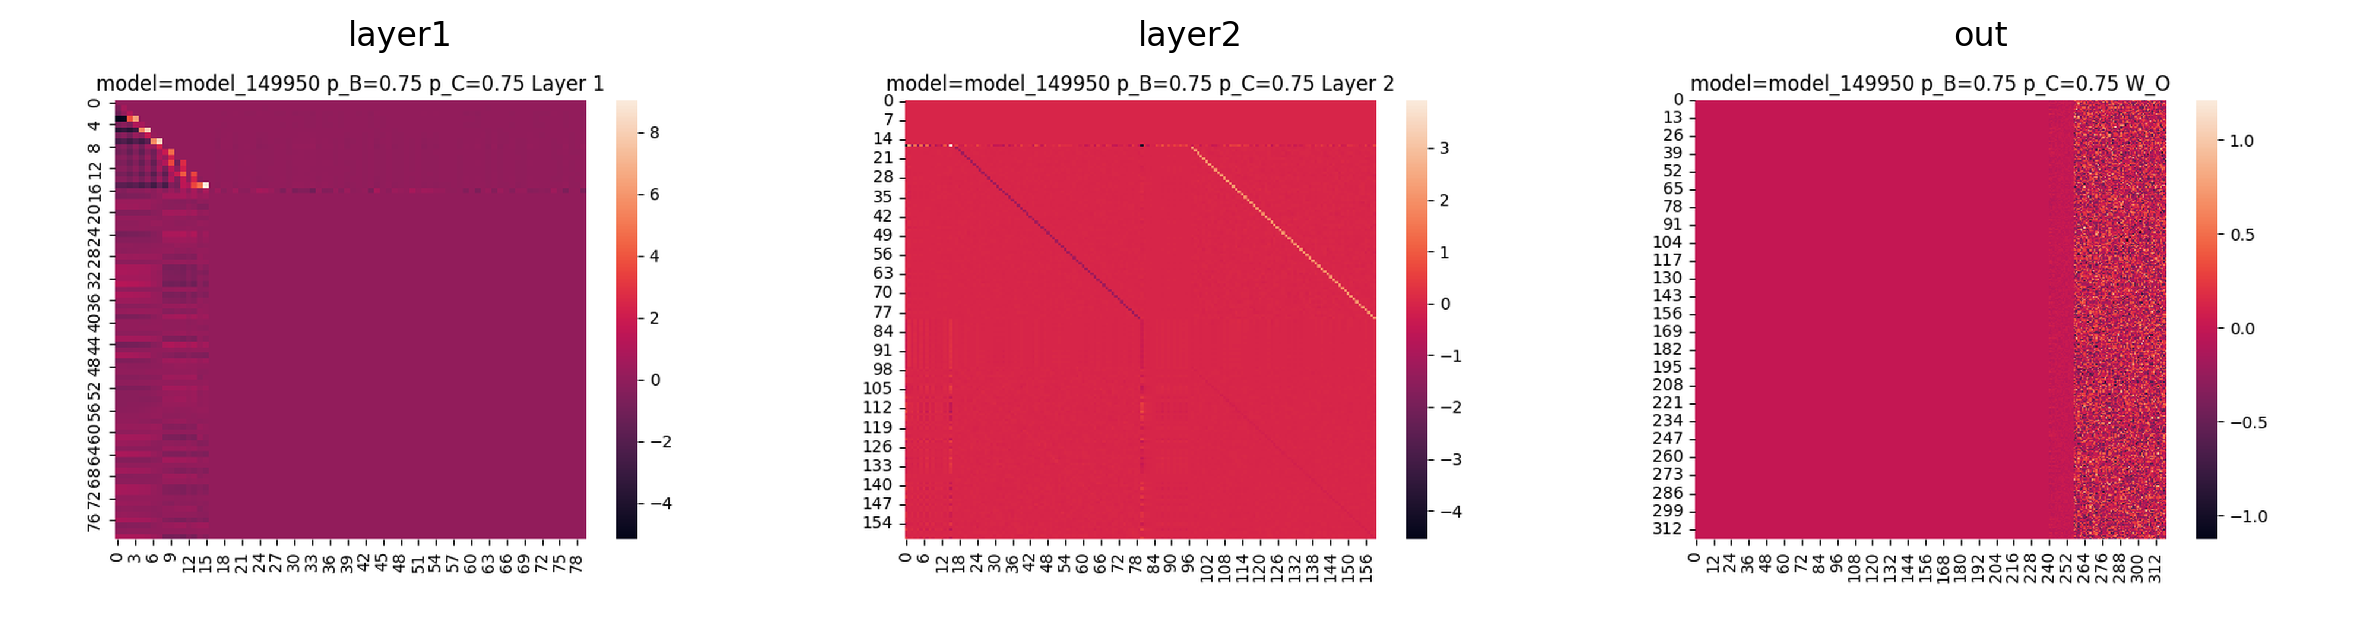

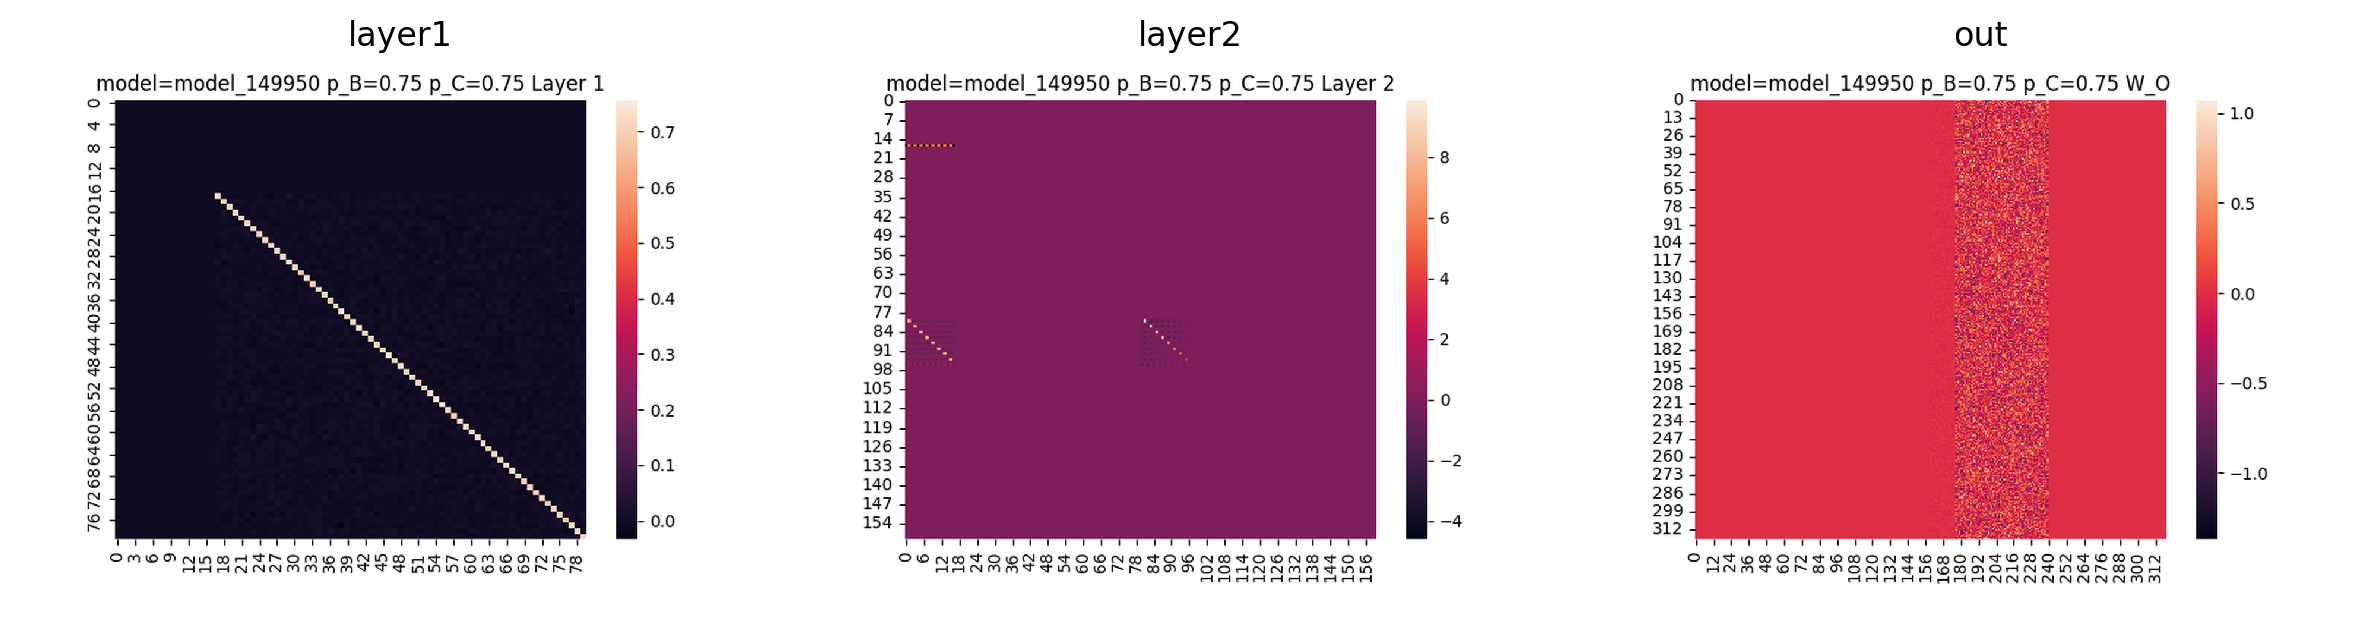

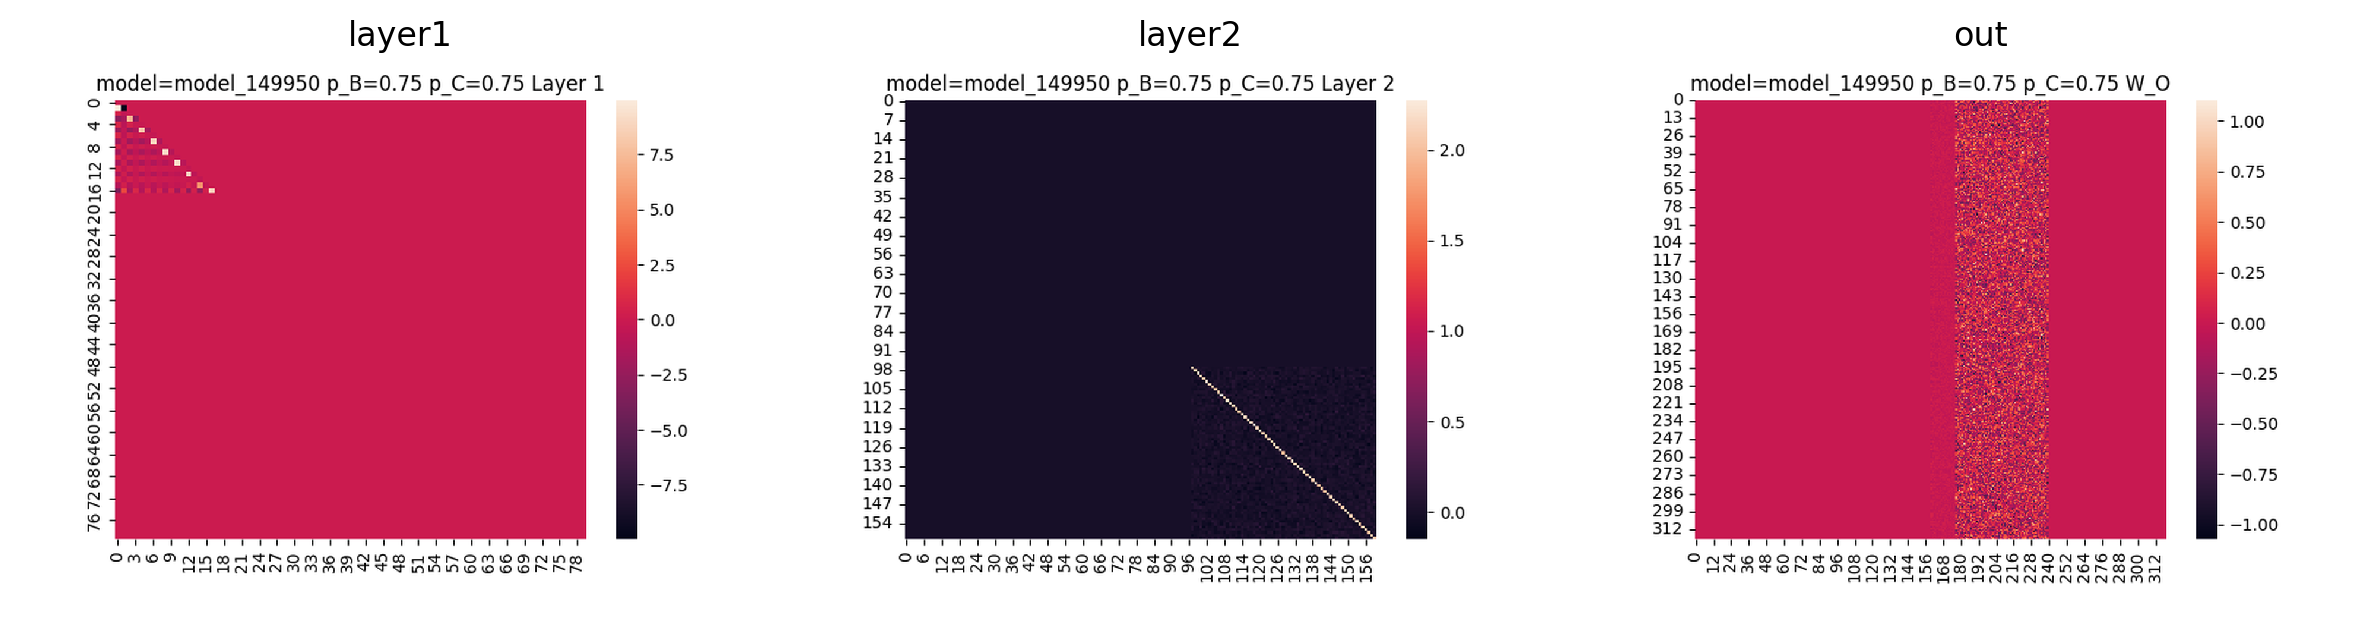

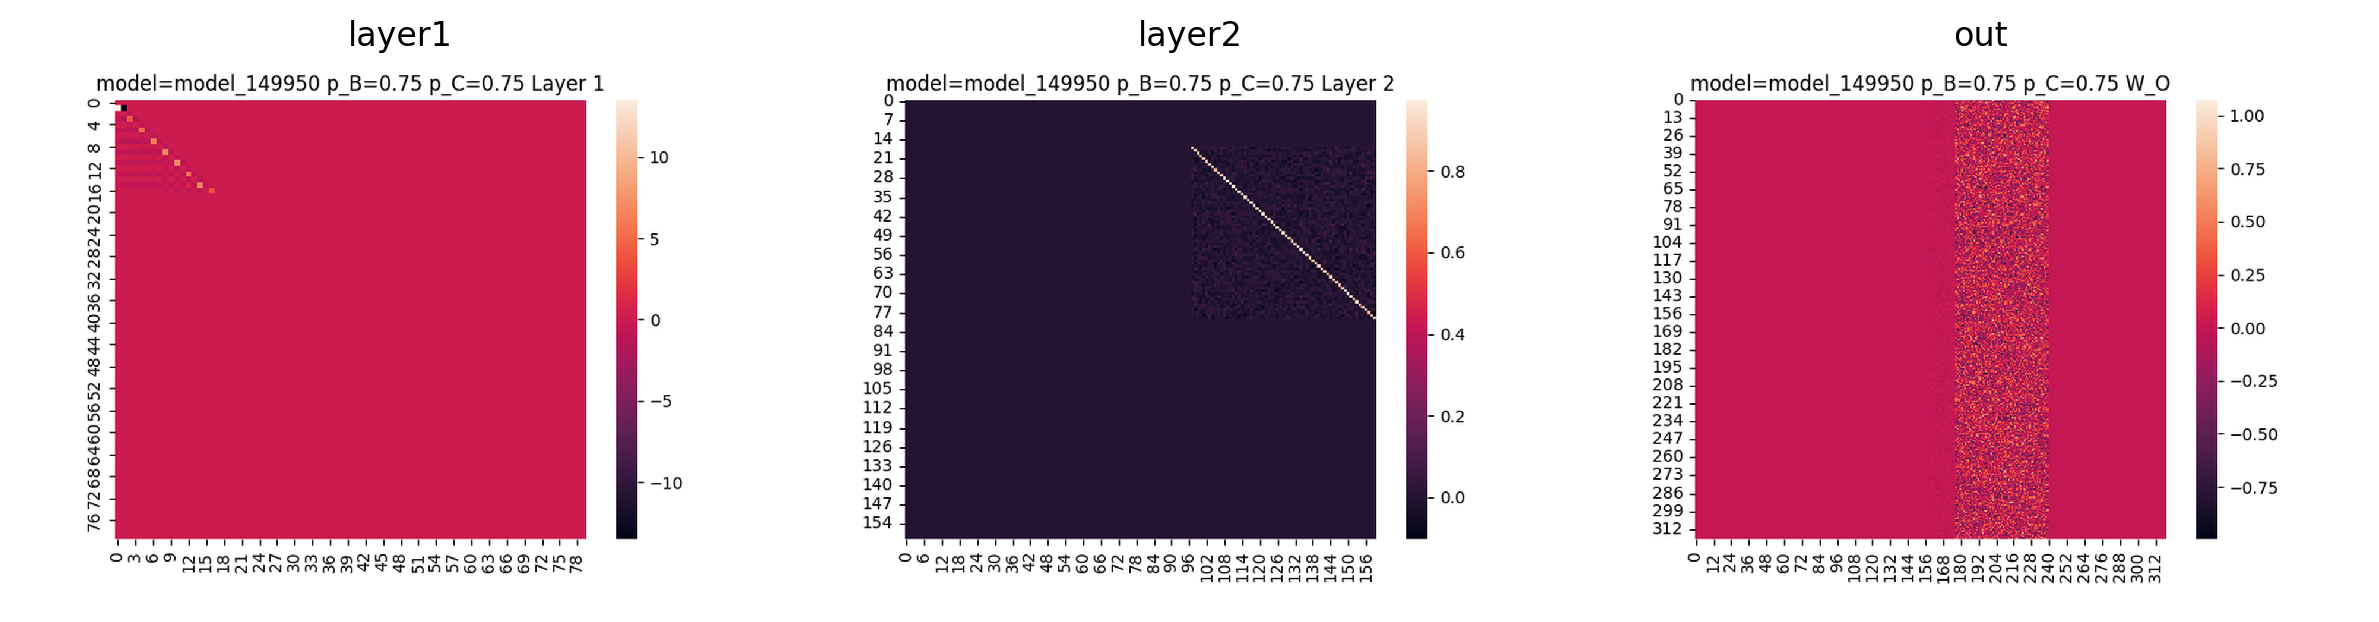

In [4]:
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import numpy as np
from PIL import Image

# ─── CONFIG ──────────────────────────────────────────────────────────────
image_dir    = Path("./")   # ← point this at your PNG folder
pattern      = "*_model_149950_*_weights_vis.png"
scale_factor = 2     # 2× linear upsampling
figure_dpi   = 200   # render the matplotlib figure at 200 dpi

# ─── GROUP FILES BY PLOT_NUMBER ──────────────────────────────────────────
groups = defaultdict(list)
for img_path in image_dir.glob(pattern):
    parts       = img_path.stem.split("_")
    plot_number = parts[0]
    layer_type  = parts[3]
    groups[plot_number].append((layer_type, img_path))

# ─── FOR EACH GROUP: CROP, UPSAMPLE, AND PLOT ────────────────────────────
for plot_number, items in groups.items():
    items.sort(key=lambda x: x[0])      # sort by layer name (optional)
    n_layers = len(items)

    # create subplots at higher DPI
    fig, axes = plt.subplots(
        1, n_layers,
        figsize=(4 * n_layers, 4),   # 4″ tall, 4″ per column
        dpi=figure_dpi
    )
    if n_layers == 1:
        axes = [axes]

    for ax, (layer_type, img_path) in zip(axes, items):
        # 1) load & crop
        pil = Image.open(img_path).convert("RGB")
        w, h = pil.size
        cropped = pil.crop((0, 25, w, h))  # drop top 25 px

        # 2) upsample
        new_size = (w * scale_factor, (h - 25) * scale_factor)
        up = cropped.resize(new_size, resample=Image.LANCZOS)

        # 3) to array & display
        img_arr = np.array(up)
        ax.imshow(img_arr, interpolation="nearest")
        ax.set_title(layer_type, fontsize=12)
        ax.axis("off")

    # fig.suptitle(f"Plot {plot_number} (cropped + {scale_factor}× upsampled)", fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

    # ─── optionally save at high DPI ─────────────────────────────────────
    # out_path = image_dir / f"{plot_number}_combined_highres.png"
    # fig.savefig(out_path, dpi=figure_dpi)
